# Mixed-Type Recommender Systems: Implementation on MovieLens-1M

**Author:** Olusola Timothy Ogundepo  
**Supervisor:** Professor Ernest Fokoué  
**Institution:** African Institute for Mathematical Sciences (AIMS), Rwanda  
**Date:** April 2026

---

## Overview

This notebook contains the full implementation of the three recommender system models developed for my AIMS Rwanda research thesis. The central question is how different modelling families handle datasets that mix numerical, categorical, and binary features alongside user-item interaction data.

The three models are evaluated on the **MovieLens-1M** dataset under identical conditions, same data splits, same evaluation metrics, so that any difference in performance can be attributed to the modelling approach rather than experimental setup.

| Model | Approach | Mixed-Type Handling |
|---|---|---|
| Matrix Factorisation | Collaborative filtering baseline | None - ratings only |
| CatBoost | Tree-based gradient boosting | Native coordinate splits |
| LightGCN | Graph neural network | Input encoding + graph propagation |

**Evaluation metrics:** RMSE, MAE (prediction accuracy) and Precision@10, Recall@10, NDCG@10 (ranking quality).  
**Split strategy:** Time-based (train on oldest 80% of ratings, validate on next 10%, test on most recent 10%).

---
## Part 1: Setup

Imports and global configuration shared across all parts of the notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
DATA_DIR = Path().resolve() / 'datasets'

---
## Part 2: Data Loading and Exploration

MovieLens-1M consists of three files. Each uses `::` as a delimiter and has no header row.

- `ratings.dat`:  1,000,209 ratings from 6,040 users on ~3,900 movies
- `users.dat` (demographic attributes): gender (binary), age (ordinal bins), occupation (categorical)
- `movies.dat`:  movie title (with year) and pipe-separated genre flags (18 genres)

First, let's load them separately, inspect each, then merge into a single working DataFrame.

In [4]:
# Load ratings
ratings = pd.read_csv(
    DATA_DIR / 'ratings.dat',
    sep='::', header=None,
    names=['user_id', 'movie_id', 'rating', 'timestamp']
)

# Load users
users = pd.read_csv(
    DATA_DIR / 'users.dat',
    sep='::', header=None,
    names=['user_id', 'gender', 'age', 'occupation', 'zip_code']
)

# Load movies
movies = pd.read_csv(
    DATA_DIR / 'movies.dat',
    sep='::', header=None,
    names=['movie_id', 'title', 'genres'],
    encoding='latin-1'
)

In [5]:
print(f'Ratings:\t{ratings.shape}')
print(f'Users:\t\t{users.shape}')
print(f'Movies:\t\t{movies.shape}')

Ratings:	(1000209, 4)
Users:		(6040, 5)
Movies:		(3883, 3)


In [6]:

print('\nratings sample:')
print(ratings.head(4).to_string(index=False))

print('\nusers sample:')
print(users.head(4).to_string(index=False))

print('\nmovies sample:')
print(movies.head(4).to_string(index=False))


ratings sample:
 user_id  movie_id  rating  timestamp
       1      1193       5  978300760
       1       661       3  978302109
       1       914       3  978301968
       1      3408       4  978300275

users sample:
 user_id gender  age  occupation zip_code
       1      F    1          10    48067
       2      M   56          16    70072
       3      M   25          15    55117
       4      M   45           7    02460

movies sample:
 movie_id                    title                       genres
        1         Toy Story (1995)  Animation|Children's|Comedy
        2           Jumanji (1995) Adventure|Children's|Fantasy
        3  Grumpier Old Men (1995)               Comedy|Romance
        4 Waiting to Exhale (1995)                 Comedy|Drama


In [7]:
# Basic statistics
n_users = ratings['user_id'].nunique()
n_movies = ratings['movie_id'].nunique()
n_zip_codes = users['zip_code'].nunique()
n_ratings = len(ratings)
sparsity = 1 - n_ratings / (n_users * n_movies)

print(f'Users:\t\t{n_users:,}')
print(f'Movies:\t\t{n_movies:,}')
print(f'Zip codes:\t{n_zip_codes:,}')
print(f'Ratings:\t{n_ratings:,}')
print(f'Sparsity:\t{sparsity:.2%}')
print(f'Rating range:\t{ratings["rating"].min()} - {ratings["rating"].max()}')
print(f'Mean rating:\t{ratings["rating"].mean():.3f}', end='\n\n')
print(f'Missing values:\n{ratings.isnull().sum().to_string()}', end='\n\n')
print(f'{users.isnull().sum().to_string()}', end='\n\n')
print(f'{movies.isnull().sum().to_string()}')

Users:		6,040
Movies:		3,706
Zip codes:	3,439
Ratings:	1,000,209
Sparsity:	95.53%
Rating range:	1 - 5
Mean rating:	3.582

Missing values:
user_id      0
movie_id     0
rating       0
timestamp    0

user_id       0
gender        0
age           0
occupation    0
zip_code      0

movie_id    0
title       0
genres      0


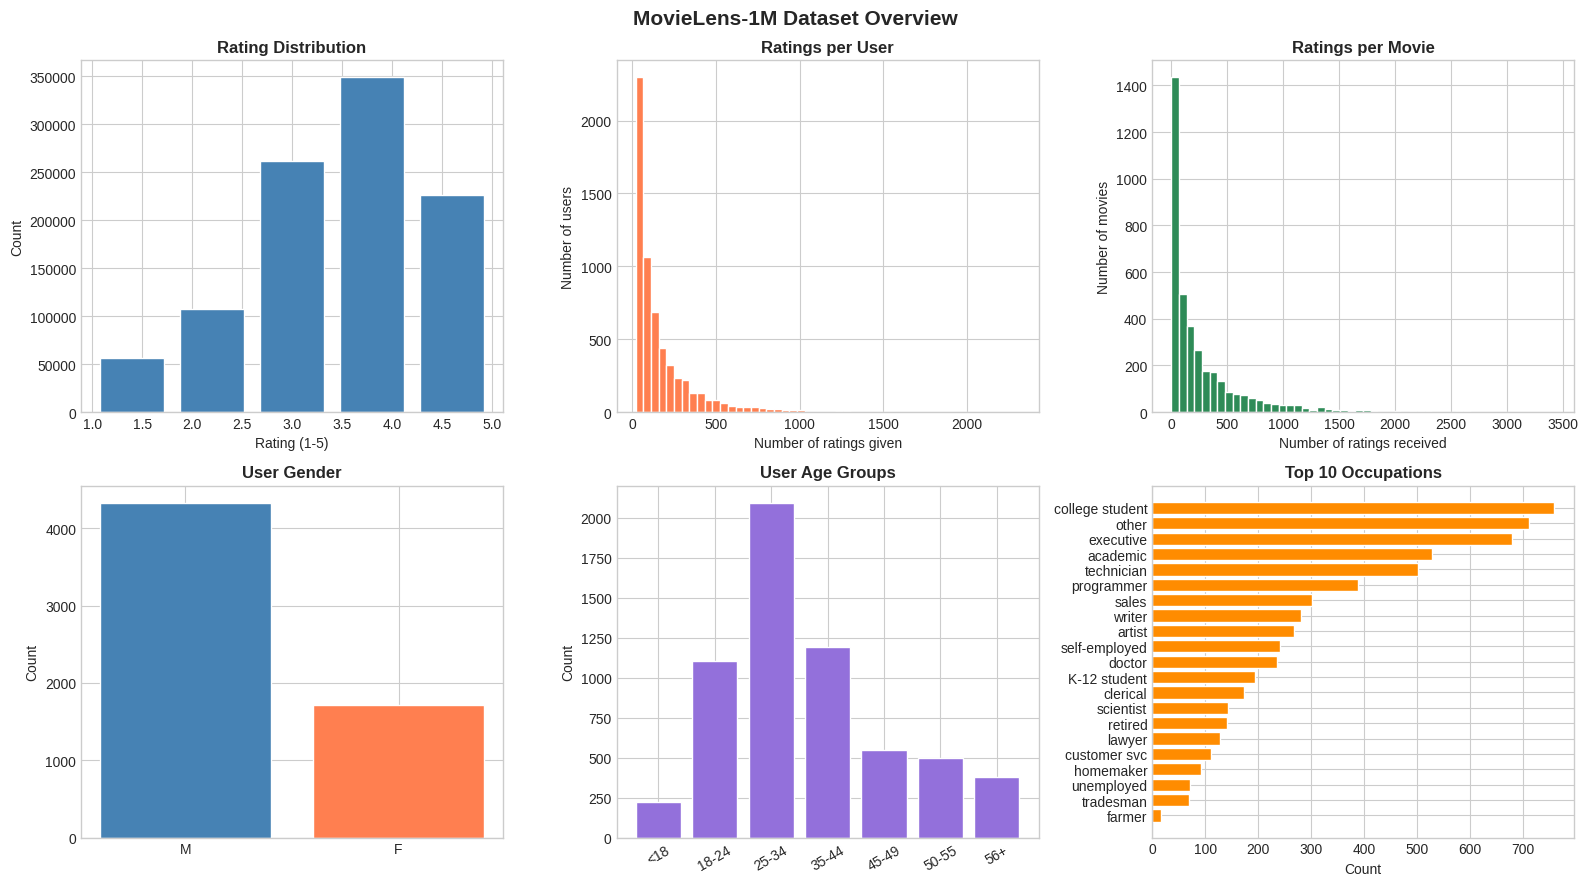

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Rating distribution
axes[0, 0].hist(ratings['rating'], bins=5, color='steelblue', edgecolor='white', rwidth=0.8)
axes[0, 0].set_title('Rating Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Rating (1-5)')
axes[0, 0].set_ylabel('Count')

# Ratings per user
ratings_per_user = ratings.groupby('user_id').size()
axes[0, 1].hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
axes[0, 1].set_title('Ratings per User', fontweight='bold')
axes[0, 1].set_xlabel('Number of ratings given')
axes[0, 1].set_ylabel('Number of users')

# Ratings per movie
ratings_per_movie = ratings.groupby('movie_id').size()
axes[0, 2].hist(ratings_per_movie, bins=50, color='seagreen', edgecolor='white')
axes[0, 2].set_title('Ratings per Movie', fontweight='bold')
axes[0, 2].set_xlabel('Number of ratings received')
axes[0, 2].set_ylabel('Number of movies')

# Gender distribution
gender_counts = users['gender'].value_counts()
axes[1, 0].bar(gender_counts.index, gender_counts.values, color=['steelblue', 'coral'], edgecolor='white')
axes[1, 0].set_title('User Gender', fontweight='bold')
axes[1, 0].set_ylabel('Count')

# Age distribution
age_labels = {1: '<18', 18: '18-24', 25: '25-34', 35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
age_counts = users['age'].value_counts().sort_index()
axes[1, 1].bar([age_labels[a] for a in age_counts.index], age_counts.values, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('User Age Groups', fontweight='bold')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=30)

# Top 10 occupations
occ_map = {
    0: 'other', 1: 'academic', 2: 'artist', 3: 'clerical', 4: 'college student',
    5: 'customer svc', 6: 'doctor', 7: 'executive', 8: 'farmer', 9: 'homemaker',
    10: 'K-12 student', 11: 'lawyer', 12: 'programmer', 13: 'retired',
    14: 'sales', 15: 'scientist', 16: 'self-employed', 17: 'technician',
    18: 'tradesman', 19: 'unemployed', 20: 'writer'
}
occ_counts = users['occupation'].value_counts()
occ_counts.index = occ_counts.index.map(occ_map)
axes[1, 2].barh(occ_counts.index[::-1], occ_counts.values[::-1], color='darkorange', edgecolor='white')
axes[1, 2].set_title('Top 10 Occupations', fontweight='bold')
axes[1, 2].set_xlabel('Count')

plt.suptitle('MovieLens-1M Dataset Overview', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3: Feature Engineering

Before any model sees the data, I need to prepare the mixed-type features shared across all three pipelines. This is done once here so that every model is evaluated on an identical representation.

**User features:**
- `age` already a numerical value (1, 18, 25, 35, 45, 50, 56); and it can be treated as continuous and scaled using min-max $[0,1]$
- `gender` binary (M $\rightarrow 1$, F $\rightarrow 0$)
- `occupation` categorical (21 classes); kept as integer label for CatBoost (which handles it natively) and one-hot encoded where required

**Item features:**
- `year`: extracted from the title string (e.g. `Toy Story (1995)` $\rightarrow$ 1995); min-max help scale this to $[0,1]$
- 18 genre flags: each genre becomes a binary column (1 if the movie belongs to that genre, 0 otherwise)

**Split strategy:** time-based on the rating timestamp, oldest 80% for training, next 10% for validation, most recent 10% for testing. This reflects the real deployment scenario, a model always predicts future preferences from past behaviour.

In [9]:
# User features
users_feat = users[['user_id', 'gender', 'age', 'occupation']].copy()
users_feat['gender'] = (users_feat['gender'] == 'M').astype(int)

scaler_age = MinMaxScaler()
users_feat['age_scaled'] = scaler_age.fit_transform(users_feat[['age']])

print('user features:')
print(users_feat.head(4).to_string(index=False))

user features:
 user_id  gender  age  occupation  age_scaled
       1       0    1          10    0.000000
       2       1   56          16    1.000000
       3       1   25          15    0.436364
       4       1   45           7    0.800000


In [10]:
# Item features
ALL_GENRES = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime',
    'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
    'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western'
]

movies_feat = movies[['movie_id', 'title', 'genres']].copy()
movies_feat['year'] = movies_feat['title'].str.extract(r'\((\d{4})\)').astype(float)

for genre in ALL_GENRES:
    movies_feat[genre] = movies_feat['genres'].str.contains(genre, regex=False).astype(int)

scaler_year = MinMaxScaler()
movies_feat['year_scaled'] = scaler_year.fit_transform(movies_feat[['year']])

print(f'item features shape: {movies_feat.shape}')
print(f'year range: {int(movies_feat["year"].min())} - {int(movies_feat["year"].max())}')
print(f'missing years: {movies_feat["year"].isna().sum()}')
print('\nsample (first 4 rows, selected columns):')
print(movies_feat[['movie_id', 'title', 'year_scaled'] + ALL_GENRES[:4]].head(4).to_string(index=False))

item features shape: (3883, 23)
year range: 1919 - 2000
missing years: 0

sample (first 4 rows, selected columns):
 movie_id                    title  year_scaled  Action  Adventure  Animation  Children's
        1         Toy Story (1995)     0.938272       0          0          1           1
        2           Jumanji (1995)     0.938272       0          1          0           1
        3  Grumpier Old Men (1995)     0.938272       0          0          0           0
        4 Waiting to Exhale (1995)     0.938272       0          0          0           0


In [11]:
# Time-based train / val / test split
ratings_sorted = ratings.sort_values('timestamp').reset_index(drop=True)

n = len(ratings_sorted)
train_end = int(n * 0.80)
val_end = int(n * 0.90)

train_raw = ratings_sorted.iloc[:train_end].copy()
val_raw = ratings_sorted.iloc[train_end:val_end].copy()
test_raw = ratings_sorted.iloc[val_end:].copy()

In [12]:
def date_extractor(df, minimum=True):
    if minimum:
        return pd.to_datetime(df["timestamp"].min(), unit="s").date()
    else:
        return pd.to_datetime(df["timestamp"].max(), unit="s").date()

print(f'Train:\t{len(train_raw):,}\tratings ({len(train_raw)/n:.0%})')
print(f'Val:\t{len(val_raw):,}\tratings ({len(val_raw)/n:.0%})')
print(f'Test:\t{len(test_raw):,}\tratings ({len(test_raw)/n:.0%})')

print(f'\nTrain timestamp range: \t{date_extractor(train_raw, True)}'
      f' to {date_extractor(train_raw, False)}')
print(f'Val timestamp range: \t{date_extractor(val_raw, True)} to '
      f'{date_extractor(val_raw, False)}')
print(f'Test timestamp range: \t{date_extractor(test_raw, True)} to '
      f'{date_extractor(test_raw, False)}')

Train:	800,167	ratings (80%)
Val:	100,021	ratings (10%)
Test:	100,021	ratings (10%)

Train timestamp range: 	2000-04-25 to 2000-12-02
Val timestamp range: 	2000-12-02 to 2000-12-29
Test timestamp range: 	2000-12-29 to 2003-02-28


---
## Part 4: Matrix Factorisation (Baseline)

Matrix factorisation is the standard collaborative filtering baseline. It uses **only the rating matrix**: no user or item attributes at all. Any gain from CatBoost or LightGCN above this baseline is attributable to the mixed-type features they additionally exploit.

The rating matrix $R \in \mathbb{R}^{m \times n}$ is approximated as a product of two low-rank matrices:

$$R \approx PQ^\top, \quad P \in \mathbb{R}^{m \times k},\ Q \in \mathbb{R}^{n \times k}$$

where $\mathbf{p}_u \in \mathbb{R}^k$ is a latent user embedding and $\mathbf{q}_i \in \mathbb{R}^k$ is a latent item embedding. The predicted rating, including user bias $b_u$, item bias $b_i$, and global mean $\mu$, is:

$$\hat{r}_{ui} = \mu + b_u + b_i + \mathbf{p}_u \cdot \mathbf{q}_i$$

Training minimises the regularised squared error over observed ratings:

$$\mathcal{L} = \sum_{(u,i) \in \mathcal{K}} \left(r_{ui} - \hat{r}_{ui}\right)^2 + \lambda\left(\|\mathbf{p}_u\|^2 + \|\mathbf{q}_i\|^2 + b_u^2 + b_i^2\right)$$

Parameters are updated by stochastic gradient descent (SGD). At each step, the error is $e_{ui} = r_{ui} - \hat{r}_{ui}$ and the updates are:

$$\mathbf{p}_u \leftarrow \mathbf{p}_u + \alpha\left(e_{ui}\,\mathbf{q}_i - \lambda\,\mathbf{p}_u\right)$$
$$\mathbf{q}_i \leftarrow \mathbf{q}_i + \alpha\left(e_{ui}\,\mathbf{p}_u - \lambda\,\mathbf{q}_i\right)$$
$$b_u \leftarrow b_u + \alpha\left(e_{ui} - \lambda\, b_u\right), \quad b_i \leftarrow b_i + \alpha\left(e_{ui} - \lambda\, b_i\right)$$

where $\alpha$ is the learning rate and $\lambda$ is the regularisation coefficient.

In [13]:
all_user_ids = sorted(ratings['user_id'].unique())
all_movie_ids = sorted(ratings['movie_id'].unique())

user_to_idx = {u: i for i, u in enumerate(all_user_ids)}
movie_to_idx = {m: i for i, m in enumerate(all_movie_ids)}

n_u = len(all_user_ids)
n_m = len(all_movie_ids)

print(f'Users in index:\t{n_u:,}')
print(f'Movies in index:\t{n_m:,}')

Users in index:	6,040
Movies in index:	3,706


In [14]:
class MatrixFactorisation:
    """
    SGD-based matrix factorisation with user/item biases.
    Prediction: r_hat = mu + b_u + b_i + p_u . q_i
    """
    def __init__(self, n_users, n_items, k=20, lr=0.005, reg=0.02, n_epochs=20):
        self.k = k
        self.lr = lr
        self.reg = reg
        self.n_epochs = n_epochs
        self.P = np.random.normal(0, 0.1, (n_users, k))
        self.Q = np.random.normal(0, 0.1, (n_items, k))
        self.b_u = np.zeros(n_users)
        self.b_i = np.zeros(n_items)
        self.mu = 0.0

    def fit(self, train_df, val_df=None):
        self.mu = train_df['rating'].mean()
        u_idx = train_df['user_id'].map(user_to_idx).values
        i_idx = train_df['movie_id'].map(movie_to_idx).values
        r = train_df['rating'].values.astype(float)

        for epoch in range(self.n_epochs):
            order = np.random.permutation(len(r))
            for idx in order:
                u, i, rui = u_idx[idx], i_idx[idx], r[idx]
                e = rui - (self.mu + self.b_u[u] + self.b_i[i] + self.P[u] @ self.Q[i])
                self.P[u] += self.lr * (e * self.Q[i] - self.reg * self.P[u])
                self.Q[i] += self.lr * (e * self.P[u] - self.reg * self.Q[i])
                self.b_u[u] += self.lr * (e - self.reg * self.b_u[u])
                self.b_i[i] += self.lr * (e - self.reg * self.b_i[i])

            if val_df is not None and (epoch + 1) % 5 == 0:
                val_rmse = self._rmse(val_df)
                print(f'  epoch {epoch+1:>2}/{self.n_epochs}  val RMSE: {val_rmse:.4f}')

    def predict(self, user_id, movie_id):
        u = user_to_idx.get(user_id)
        i = movie_to_idx.get(movie_id)
        if u is None or i is None:
            return self.mu
        return float(np.clip(self.mu + self.b_u[u] + self.b_i[i] + self.P[u] @ self.Q[i], 1.0, 5.0))

    def _rmse(self, df):
        preds = [self.predict(r.user_id, r.movie_id) for r in df.itertuples()]
        return float(np.sqrt(mean_squared_error(df['rating'].values, preds)))

In [15]:
mf = MatrixFactorisation(n_u, n_m, k=20, lr=0.005, reg=0.02, n_epochs=20)
print('Training MF (SGD, 20 epochs)...')
mf.fit(train_raw, val_df=val_raw)

Training MF (SGD, 20 epochs)...
  epoch  5/20  val RMSE: 0.9732
  epoch 10/20  val RMSE: 0.9686
  epoch 15/20  val RMSE: 0.9654
  epoch 20/20  val RMSE: 0.9648


In [16]:
test_preds = [mf.predict(r.user_id, r.movie_id) for r in test_raw.itertuples()]
test_actuals = test_raw['rating'].values.astype(float)

mf_rmse = float(np.sqrt(mean_squared_error(test_actuals, test_preds)))
mf_mae  = float(mean_absolute_error(test_actuals, test_preds))

print(f'MF  RMSE:\t{mf_rmse:.4f}')
print(f'MF  MAE:\t{mf_mae:.4f}')

MF  RMSE:	0.9155
MF  MAE:	0.7170


In [17]:
def ranking_metrics(model_predict, test_df, train_df, K=10, threshold=4.0, n_users=200):
    """
    Compute Precision@K, Recall@K and NDCG@K for a given predict function.
    Evaluates on a random sample of test users who have at least 1 relevant item.
    """
    train_seen = train_df.groupby('user_id')['movie_id'].apply(set).to_dict()
    test_relevant = (
        test_df[test_df['rating'] >= threshold]
        .groupby('user_id')['movie_id'].apply(set).to_dict()
    )

    rng = np.random.default_rng(42)
    candidates = [u for u in test_relevant if len(test_relevant[u]) > 0]
    sampled = rng.choice(candidates, size=min(n_users, len(candidates)), replace=False)

    p_scores, r_scores, ndcg_scores = [], [], []

    for uid in sampled:
        seen = train_seen.get(uid, set())
        relevant = test_relevant[uid]
        unrated = [m for m in all_movie_ids if m not in seen]

        scores = np.array([model_predict(uid, m) for m in unrated])
        top_k = [unrated[j] for j in np.argsort(scores)[::-1][:K]]

        hits = [1.0 if m in relevant else 0.0 for m in top_k]
        precision = sum(hits) / K
        recall = sum(hits) / len(relevant) if relevant else 0.0

        dcg = sum(h / np.log2(r + 2) for r, h in enumerate(hits))
        ideal = sum(1.0 / np.log2(r + 2) for r in range(min(K, len(relevant))))
        ndcg = dcg / ideal if ideal > 0 else 0.0

        p_scores.append(precision)
        r_scores.append(recall)
        ndcg_scores.append(ndcg)

    return np.mean(p_scores), np.mean(r_scores), np.mean(ndcg_scores)


mf_p10, mf_r10, mf_ndcg10 = ranking_metrics(mf.predict, test_raw, train_raw, K=10)
print(f'MF  Precision@10:\t{mf_p10:.4f}')
print(f'MF  Recall@10:\t\t{mf_r10:.4f}')
print(f'MF  NDCG@10:\t\t{mf_ndcg10:.4f}')

MF  Precision@10:	0.1230
MF  Recall@10:		0.0345
MF  NDCG@10:		0.1283


In [18]:
def recommend_top_k(model_predict, user_id, train_df, k=10):
    seen = set(train_df[train_df['user_id'] == user_id]['movie_id'])
    unrated = [m for m in all_movie_ids if m not in seen]
    scores = np.array([model_predict(user_id, m) for m in unrated])
    top_idx = np.argsort(scores)[::-1][:k]
    top_ids = [unrated[j] for j in top_idx]
    top_scores = scores[top_idx]
    result = movies_feat[movies_feat['movie_id'].isin(top_ids)][['movie_id', 'title']].copy()
    score_map = dict(zip(top_ids, top_scores))
    result['pred_score'] = result['movie_id'].map(score_map).round(3)
    return result.sort_values('pred_score', ascending=False).reset_index(drop=True)


sample_user = 1
print(f'Top-10 recommendations for user {sample_user} (MF):')
print(recommend_top_k(mf.predict, sample_user, train_raw).to_string(index=False))

Top-10 recommendations for user 1 (MF):
 movie_id                            title  pred_score
     2905                   Sanjuro (1962)       4.695
      318 Shawshank Redemption, The (1994)       4.486
     3949       Requiem for a Dream (2000)       4.470
     1262         Great Escape, The (1963)       4.470
     1240           Terminator, The (1984)       4.446
      858            Godfather, The (1972)       4.443
     1198   Raiders of the Lost Ark (1981)       4.442
       50       Usual Suspects, The (1995)       4.441
     3306               Circus, The (1928)       4.439
     3038      Face in the Crowd, A (1957)       4.435


---
## Part 5: CatBoost (Gradient Boosting with Native Categorical Handling)

CatBoost converts rating prediction into a supervised regression problem. Each training example is a (user, movie) pair represented as a fixed-length feature vector, and the model fits an ensemble of $M$ gradient-boosted oblivious trees:

$$\hat{r}_{ui} = F_M(z_u, x_i) = \sum_{m=1}^{M} \gamma_m\, h_m(z_u, x_i)$$

where $\gamma_m$ is the weight of tree $m$ and $M$ is determined by early stopping on validation RMSE. Two feature configurations are evaluated:

- **Part 5a (base, 22 features):** raw demographic and item side features only, no interaction history.
- **Part 5b (extended, 42 features):** adds user genre affinities and item statistics derived from training ratings.


### Part 5a: CatBoost Base (22 Features)

A minimal configuration using only the raw side features: $z_u = (g_u,\ a_u,\ o_u)$ and $x_i = (y_i,\ x_{i,1},\ldots,x_{i,18})$, giving 22 features in total. No statistics are pre-computed from training ratings.


In [19]:
from catboost import CatBoostRegressor, Pool

# Base feature columns: 3 user demo + 1 year + 18 genres = 22 features, no interaction history
FEATURE_COLS_BASE = (
    ['gender', 'age_scaled', 'occupation']
    + ['year_scaled']
    + ALL_GENRES
)
CAT_COLS_BASE = ['occupation']

def build_cb_base_df(ratings_df):
    df = ratings_df.merge(
        users_feat[['user_id', 'gender', 'age_scaled', 'occupation']], on='user_id'
    )
    df = df.merge(
        movies_feat[['movie_id', 'year_scaled'] + ALL_GENRES], on='movie_id'
    )
    return df

train_cb_base = build_cb_base_df(train_raw)
val_cb_base = build_cb_base_df(val_raw)
test_cb_base = build_cb_base_df(test_raw)

print(f'Features (base):\t{len(FEATURE_COLS_BASE)}  ({len(CAT_COLS_BASE)} categorical: {CAT_COLS_BASE})')

train_pool_base = Pool(train_cb_base[FEATURE_COLS_BASE], train_cb_base['rating'], cat_features=CAT_COLS_BASE)
val_pool_base = Pool(val_cb_base[FEATURE_COLS_BASE],   val_cb_base['rating'],   cat_features=CAT_COLS_BASE)

cb_base_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=20,
    verbose=50
)

print('Training CatBoost (base)...')
cb_base_model.fit(train_pool_base, eval_set=val_pool_base)


Features (base):	22  (1 categorical: ['occupation'])
Training CatBoost (base)...
0:	learn: 1.1171556	test: 1.1161504	best: 1.1161504 (0)	total: 129ms	remaining: 1m 4s
50:	learn: 1.0742256	test: 1.0773157	best: 1.0773157 (50)	total: 2.65s	remaining: 23.3s
100:	learn: 1.0652097	test: 1.0702862	best: 1.0702862 (100)	total: 5.1s	remaining: 20.2s
150:	learn: 1.0589796	test: 1.0652455	best: 1.0652455 (150)	total: 7.54s	remaining: 17.4s
200:	learn: 1.0544962	test: 1.0617886	best: 1.0617886 (200)	total: 9.97s	remaining: 14.8s
250:	learn: 1.0510505	test: 1.0594810	best: 1.0594810 (250)	total: 12.5s	remaining: 12.4s
300:	learn: 1.0481097	test: 1.0571883	best: 1.0571883 (300)	total: 15.1s	remaining: 9.98s
350:	learn: 1.0457884	test: 1.0550817	best: 1.0550817 (350)	total: 17.6s	remaining: 7.48s
400:	learn: 1.0438772	test: 1.0539156	best: 1.0539036 (397)	total: 20.1s	remaining: 4.95s
450:	learn: 1.0422810	test: 1.0528746	best: 1.0528746 (450)	total: 22.4s	remaining: 2.43s
499:	learn: 1.0406230	test

CatBoostRegressor(depth=6, early_stopping_rounds=20, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=50)

In [20]:
cb_base_test_preds = np.clip(cb_base_model.predict(test_cb_base[FEATURE_COLS_BASE]), 1.0, 5.0)

cb_base_rmse = float(np.sqrt(mean_squared_error(test_cb_base['rating'], cb_base_test_preds)))
cb_base_mae = float(mean_absolute_error(test_cb_base['rating'], cb_base_test_preds))

print(f'CatBoost (base)  RMSE:\t{cb_base_rmse:.4f}')
print(f'CatBoost (base)  MAE:\t{cb_base_mae:.4f}')

CatBoost (base)  RMSE:	1.0195
CatBoost (base)  MAE:	0.8214


In [21]:

# Prediction caches for ranking metrics
uf_base = users_feat.set_index('user_id')[['gender', 'age_scaled', 'occupation']]
mf_base = movies_feat.set_index('movie_id')[['year_scaled'] + ALL_GENRES]

cb_base_user_cache = {
    uid: (
        int(uf_base.at[uid, 'gender']),
        float(uf_base.at[uid, 'age_scaled']),
        int(uf_base.at[uid, 'occupation'])
    )
    for uid in all_user_ids
}

cb_base_movie_cache = {
    mid: tuple(mf_base.loc[mid].values.astype(float).tolist())
    for mid in all_movie_ids
}

def cb_base_predict(user_id, movie_id):
    uf  = cb_base_user_cache.get(user_id)
    mfv = cb_base_movie_cache.get(movie_id)
    if uf is None or mfv is None:
        return float(mu_train)
    row = np.array([*uf, *mfv], dtype=object).reshape(1, -1)
    return float(np.clip(cb_base_model.predict(row)[0], 1.0, 5.0))

cb_base_p10, cb_base_r10, cb_base_ndcg10 = ranking_metrics(cb_base_predict, test_raw, train_raw, K=10)
print(f'CatBoost (base)  Precision@10:\t{cb_base_p10:.4f}')
print(f'CatBoost (base)  Recall@10:\t{cb_base_r10:.4f}')
print(f'CatBoost (base)  NDCG@10:\t{cb_base_ndcg10:.4f}')

CatBoost (base)  Precision@10:	0.0595
CatBoost (base)  Recall@10:	0.0146
CatBoost (base)  NDCG@10:	0.0536


In [22]:
print(f'\nTop-10 recommendations for user {sample_user} (CatBoost base):')
print(recommend_top_k(cb_base_predict, sample_user, train_raw).to_string(index=False))


Top-10 recommendations for user 1 (CatBoost base):
 movie_id                       title  pred_score
     1151                Faust (1994)       4.538
      745       Close Shave, A (1995)       4.478
      930            Notorious (1946)       4.348
     1252            Chinatown (1974)       4.343
     1148  Wrong Trousers, The (1993)       4.330
     1223     Grand Day Out, A (1992)       4.312
      913  Maltese Falcon, The (1941)       4.302
      942                Laura (1944)       4.296
     1284       Big Sleep, The (1946)       4.294
     2186 Strangers on a Train (1951)       4.282


### Part 5b: CatBoost Extended (42 Features)

Extends Part 5a by adding 18 user genre affinities $\bar{r}_{u,k}$ (mean rating user $u$ gave to genre $k$ movies in training) and 2 item statistics ($\bar{r}_i$, $c_i$), giving:

$$z_u = \bigl(g_u,\ a_u,\ o_u,\ \bar{r}_{u,1},\ldots,\bar{r}_{u,18}\bigr), \qquad x_i = \bigl(y_i,\ x_{i,1},\ldots,x_{i,18},\ \bar{r}_i,\ c_i\bigr)$$

Occupation $o_u$ is handled natively via **ordered target statistics**, preventing target leakage without one-hot encoding. All added statistics are derived from the training set only.


In [ ]:
# Item statistics from training set only (prevents leakage)
mu_train = train_raw['rating'].mean()
item_stats = train_raw.groupby('movie_id')['rating'].agg(
    item_mean_rating='mean', item_rating_count='count'
).reset_index()

# User genre affinities: mean rating per user per genre, from training set only
train_with_genres = train_raw.merge(
    movies_feat[['movie_id'] + ALL_GENRES], on='movie_id'
)
ua_cols = [f'ua_{g}' for g in ALL_GENRES]

affinity_parts = []
for g, ua_col in zip(ALL_GENRES, ua_cols):
    aff = (
        train_with_genres[train_with_genres[g] == 1]
        .groupby('user_id')['rating']
        .mean()
        .rename(ua_col)
    )
    affinity_parts.append(aff)

user_affinity_df = (
    pd.concat(affinity_parts, axis=1)
    .reindex(all_user_ids)
    .fillna(mu_train)
    .reset_index()
)
user_affinity_df.columns = ['user_id'] + ua_cols

# 42-dimensional feature vector: 3 user demo + 18 user affinities
#                                + 1 year + 18 genres + 2 item stats
FEATURE_COLS = (
    ['gender', 'age_scaled', 'occupation']
    + ua_cols
    + ['year_scaled']
    + ALL_GENRES
    + ['item_mean_rating', 'item_rating_count']
)
CAT_COLS = ['occupation']

def build_cb_df(ratings_df):
    df = ratings_df.merge(
        users_feat[['user_id', 'gender', 'age_scaled', 'occupation']], on='user_id'
    )
    df = df.merge(user_affinity_df, on='user_id')
    df = df.merge(
        movies_feat[['movie_id', 'year_scaled'] + ALL_GENRES], on='movie_id'
    )
    df = df.merge(item_stats, on='movie_id', how='left')
    df['item_mean_rating']  = df['item_mean_rating'].fillna(mu_train)
    df['item_rating_count'] = df['item_rating_count'].fillna(0).astype(int)
    return df

train_cb = build_cb_df(train_raw)
val_cb = build_cb_df(val_raw)
test_cb  = build_cb_df(test_raw)

print(f'Train CB rows:\t{len(train_cb):,}')
print(f'Val CB rows:\t{len(val_cb):,}')
print(f'Test CB rows:\t{len(test_cb):,}')
print(f'Features:\t{len(FEATURE_COLS)}  ({len(CAT_COLS)} categorical: {CAT_COLS})')


Train CB rows:	800,167
Val CB rows:	100,021
Test CB rows:	100,021
Features:	42  (1 categorical: ['occupation'])


In [24]:
train_pool = Pool(train_cb[FEATURE_COLS], train_cb['rating'], cat_features=CAT_COLS)
val_pool = Pool(val_cb[FEATURE_COLS],   val_cb['rating'],   cat_features=CAT_COLS)

cb_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=20,
    verbose=50
)

print('Training CatBoost...')
cb_model.fit(train_pool, eval_set=val_pool)

Training CatBoost...
0:	learn: 1.1045819	test: 1.1083446	best: 1.1083446 (0)	total: 121ms	remaining: 1m
50:	learn: 0.9133331	test: 0.9815533	best: 0.9815533 (50)	total: 5.02s	remaining: 44.2s
100:	learn: 0.8995350	test: 0.9787254	best: 0.9784367 (84)	total: 9.95s	remaining: 39.3s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.9784367024
bestIteration = 84

Shrink model to first 85 iterations.


CatBoostRegressor(depth=6, early_stopping_rounds=20, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=50)

In [ ]:
cb_test_preds = np.clip(cb_model.predict(test_cb[FEATURE_COLS]), 1.0, 5.0)

cb_rmse = float(np.sqrt(mean_squared_error(test_cb['rating'], cb_test_preds)))
cb_mae = float(mean_absolute_error(test_cb['rating'], cb_test_preds))

print(f'CatBoost  RMSE:\t{cb_rmse:.4f}')
print(f'CatBoost  MAE:\t{cb_mae:.4f}')

CatBoost  RMSE:	0.9387
CatBoost  MAE:	0.7378


In [26]:
# Pre-build caches for fast per-pair prediction
uf_cb = users_feat.set_index('user_id')[['gender', 'age_scaled', 'occupation']]
ua_cb = user_affinity_df.set_index('user_id')
mf_cb = movies_feat.set_index('movie_id')[['year_scaled'] + ALL_GENRES]
istats = item_stats.set_index('movie_id')

# User cache: (gender, age_scaled, occupation, ua_0..17)  -- 21 values
cb_user_cache = {
    uid: (
        int(uf_cb.at[uid, 'gender']),
        float(uf_cb.at[uid, 'age_scaled']),
        int(uf_cb.at[uid, 'occupation']),
        *[float(ua_cb.at[uid, c]) for c in ua_cols]
    )
    for uid in all_user_ids
}

# Movie cache: (year_scaled, g1..g18, item_mean_rating, item_rating_count)  -- 21 values
cb_movie_cache = {}
for mid in all_movie_ids:
    mv = mf_cb.loc[mid].values.astype(float).tolist()
    cb_movie_cache[mid] = (
        *mv,
        float(istats.at[mid, 'item_mean_rating']) if mid in istats.index else mu_train,
        int(istats.at[mid, 'item_rating_count'])  if mid in istats.index else 0
    )

def cb_predict(user_id, movie_id):
    uf  = cb_user_cache.get(user_id)
    mfv = cb_movie_cache.get(movie_id)
    if uf is None or mfv is None:
        return float(mu_train)
    # Feature order matches FEATURE_COLS:
    # gender, age_scaled, occupation, ua_0..17,
    # year_scaled, g1..18, item_mean_rating, item_rating_count
    row = np.array(
        [*uf, *mfv],
        dtype=object
    ).reshape(1, -1)
    return float(np.clip(cb_model.predict(row)[0], 1.0, 5.0))

cb_p10, cb_r10, cb_ndcg10 = ranking_metrics(cb_predict, test_raw, train_raw, K=10)
print(f'CatBoost  Precision@10:\t{cb_p10:.4f}')
print(f'CatBoost  Recall@10:\t{cb_r10:.4f}')
print(f'CatBoost  NDCG@10:\t{cb_ndcg10:.4f}')

CatBoost  Precision@10:	0.0675
CatBoost  Recall@10:	0.0198
CatBoost  NDCG@10:	0.0733


In [27]:
sample_user = 1
print(f'Top-10 recommendations for user {sample_user} (CatBoost):')
print(recommend_top_k(cb_predict, sample_user, train_raw).to_string(index=False))

Top-10 recommendations for user 1 (CatBoost):
 movie_id                                                  title  pred_score
      745                                  Close Shave, A (1995)       4.252
      260              Star Wars: Episode IV - A New Hope (1977)       4.251
     2905                                         Sanjuro (1962)       4.251
     1198                         Raiders of the Lost Ark (1981)       4.251
     1148                             Wrong Trousers, The (1993)       4.247
      720 Wallace & Gromit: The Best of Aardman Animation (1996)       4.247
     3172                                Ulysses (Ulisse) (1954)       4.246
       50                             Usual Suspects, The (1995)       4.241
      904                                     Rear Window (1954)       4.241
     2762                                Sixth Sense, The (1999)       4.241


---
## Part 6: LightGCN (Feature-Augmented Graph Neural Network)

LightGCN models the user-item interaction graph directly. Users and items are nodes; each observed training rating is a bidirectional edge. Layer-0 embeddings combine a free learned ID embedding with a feature-driven projection:

$$h_u^{(0)} = e_u + W_u z_u, \qquad h_i^{(0)} = e_i + W_i x_i$$

where $e_u, e_i \in \mathbb{R}^d$ are free embeddings learned per node (giving the model the same personalisation capacity as MF), $z_u \in \mathbb{R}^{23}$ stacks gender, scaled age, and a 21-class occupation one-hot, and $x_i \in \mathbb{R}^{19}$ stacks scaled release year and the 18 genre flags. $W_u \in \mathbb{R}^{d \times 23}$ and $W_i \in \mathbb{R}^{d \times 19}$ are learned projection matrices that inject side-information into the embedding space.

Propagation follows the LightGCN rule, which removes weight matrices and non-linearities from the standard GNN update:

$$h_u^{(l+1)} = \sum_{i \in \mathcal{N}(u)} \frac{1}{\sqrt{|\mathcal{N}(u)|\,|\mathcal{N}(i)|}} h_i^{(l)}, \qquad h_i^{(l+1)} = \sum_{u \in \mathcal{N}(i)} \frac{1}{\sqrt{|\mathcal{N}(i)|\,|\mathcal{N}(u)|}} h_u^{(l)}$$

After $L$ layers, each node's final representation is the mean across all layer outputs (including layer 0):

$$h_u^* = \frac{1}{L+1}\sum_{l=0}^{L} h_u^{(l)}, \qquad h_i^* = \frac{1}{L+1}\sum_{l=0}^{L} h_i^{(l)}$$

Rating prediction uses an inner product plus per-user and per-item bias terms, analogous to MF, then clips to $[1, 5]$:

$$\hat{r}_{ui} = \mathrm{clip}\!\left(\mu + b_u + b_i + h_u^* \cdot h_i^*,\ 1,\ 5\right)$$

where $\mu$ is the global training mean, $b_u$ and $b_i$ are learned scalar biases. The model is trained by minimising MSE over observed training ratings with early stopping on validation RMSE.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn.conv import LGConv

# Align feature matrices to the sorted user/item ID order used everywhere else
users_feat_sorted = users_feat.set_index('user_id').reindex(all_user_ids)
movies_feat_sorted = movies_feat.set_index('movie_id').reindex(all_movie_ids)

# User features: gender (1) + age_scaled (1) + occupation one-hot (21) = 23 dims
occ_onehot = (
    pd.get_dummies(users_feat_sorted['occupation'].astype(int), dtype=np.float32)
    .reindex(columns=list(range(21)), fill_value=0.0)
    .values
)
user_feat_mat = np.hstack([
    users_feat_sorted[['gender', 'age_scaled']].values.astype(np.float32),
    occ_onehot
])

# Item features: year_scaled (1) + 18 genre flags = 19 dims
item_feat_mat = movies_feat_sorted[['year_scaled'] + ALL_GENRES].values.astype(np.float32)

USER_FEAT_DIM = user_feat_mat.shape[1]
ITEM_FEAT_DIM = item_feat_mat.shape[1]
EMB_DIM = 64
N_LAYERS = 2

user_feats_t = torch.tensor(user_feat_mat)
item_feats_t = torch.tensor(item_feat_mat)

# Bipartite graph layout: users 0..n_u-1, items n_u..n_u+n_m-1
item_offset = n_u

train_u_idx = torch.tensor(train_raw['user_id'].map(user_to_idx).values, dtype=torch.long)
train_i_idx = torch.tensor(train_raw['movie_id'].map(movie_to_idx).values, dtype=torch.long)
train_r = torch.tensor(train_raw['rating'].values, dtype=torch.float32)

val_u_idx = torch.tensor(val_raw['user_id'].map(user_to_idx).values, dtype=torch.long)
val_i_idx = torch.tensor(val_raw['movie_id'].map(movie_to_idx).values, dtype=torch.long)
val_r = torch.tensor(val_raw['rating'].values, dtype=torch.float32)

src = torch.cat([train_u_idx, train_i_idx + item_offset])
dst = torch.cat([train_i_idx + item_offset, train_u_idx])
edge_index = torch.stack([src, dst], dim=0)

mu_train = float(train_raw['rating'].mean())


class FeatureInitLightGCN(nn.Module):
    """LightGCN with feature-augmented init: h_u^(0) = e_u + W_u z_u, similarly for items."""
    def __init__(self, n_users, n_items, user_feat_dim, item_feat_dim, emb_dim, n_layers, global_mean):
        super().__init__()
        self.n_users = n_users
        self.mu = global_mean
        self.user_emb = nn.Embedding(n_users, emb_dim)
        self.item_emb = nn.Embedding(n_items, emb_dim)
        self.user_proj = nn.Linear(user_feat_dim, emb_dim)
        self.item_proj = nn.Linear(item_feat_dim, emb_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(n_layers)])
        self.user_bias = nn.Parameter(torch.zeros(n_users))
        self.item_bias = nn.Parameter(torch.zeros(n_items))
        nn.init.normal_(self.user_emb.weight, std=0.1)
        nn.init.normal_(self.item_emb.weight, std=0.1)

    def forward(self, user_feats, item_feats, edge_index):
        u0 = self.user_emb.weight + self.user_proj(user_feats)
        i0 = self.item_emb.weight + self.item_proj(item_feats)
        x = torch.cat([u0, i0], dim=0)
        all_embs = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            all_embs.append(x)
        final = torch.stack(all_embs, dim=0).mean(dim=0)
        return final[:self.n_users], final[self.n_users:]

    def predict(self, u_idx, i_idx, u_embs, i_embs):
        dot = (u_embs[u_idx] * i_embs[i_idx]).sum(dim=-1)
        return self.mu + self.user_bias[u_idx] + self.item_bias[i_idx] + dot


_tmp = FeatureInitLightGCN(n_u, n_m, USER_FEAT_DIM, ITEM_FEAT_DIM, EMB_DIM, N_LAYERS, mu_train)
n_params = sum(p.numel() for p in _tmp.parameters())

print(f'User feature dim:\t{USER_FEAT_DIM}  (gender + age + occupation one-hot)')
print(f'Item feature dim:\t{ITEM_FEAT_DIM}  (year + 18 genres)')
print(f'Embedding dim:\t\t{EMB_DIM}')
print(f'LightGCN layers:\t{N_LAYERS}')
print(f'Graph nodes:\t\t{n_u + n_m:,}  ({n_u:,} users + {n_m:,} items)')
print(f'Graph edges:\t\t{edge_index.shape[1]:,}  (bidirectional training interactions)')
print(f'Learnable parameters:\t{n_params:,}')


User feature dim:	23  (gender + age + occupation one-hot)
Item feature dim:	19  (year + 18 genres)
Embedding dim:		64
LightGCN layers:	2
Graph nodes:		9,746  (6,040 users + 3,706 items)
Graph edges:		1,600,334  (bidirectional training interactions)
Learnable parameters:	636,306  (free ID emb + feature projections + biases)


In [ ]:
# Mini-batch training. Biases learn faster with a higher lr,
# embeddings and projections share the smaller one.
torch.manual_seed(42)
lgcn_model = FeatureInitLightGCN(
    n_u, n_m, USER_FEAT_DIM, ITEM_FEAT_DIM, EMB_DIM, N_LAYERS, mu_train
)

optimizer = torch.optim.Adam([
    {'params': [lgcn_model.user_bias, lgcn_model.item_bias], 'lr': 0.05},
    {'params': list(lgcn_model.user_emb.parameters())
             + list(lgcn_model.item_emb.parameters())
             + list(lgcn_model.user_proj.parameters())
             + list(lgcn_model.item_proj.parameters()), 'lr': 0.01},
], weight_decay=1e-5)

N_EPOCHS = 30
BATCH_SIZE = 16384
PATIENCE = 5
N_TRAIN = train_u_idx.shape[0]

best_val = float('inf')
best_state = None
patience = 0

print('Training LightGCN (feature-augmented, mini-batch)...')
print(f'{"Epoch":>6} {"Train RMSE":>12} {"Val RMSE":>10}')

for epoch in range(1, N_EPOCHS + 1):
    lgcn_model.train()
    perm = torch.randperm(N_TRAIN)
    epoch_sse = 0.0

    for start in range(0, N_TRAIN, BATCH_SIZE):
        batch = perm[start:start + BATCH_SIZE]
        bu, bi, br = train_u_idx[batch], train_i_idx[batch], train_r[batch]

        optimizer.zero_grad()
        u_embs, i_embs = lgcn_model(user_feats_t, item_feats_t, edge_index)
        pred = lgcn_model.predict(bu, bi, u_embs, i_embs)
        loss = F.mse_loss(pred, br)
        loss.backward()
        optimizer.step()

        epoch_sse += loss.item() * len(batch)

    train_rmse = (epoch_sse / N_TRAIN) ** 0.5

    # Validation pass
    lgcn_model.eval()
    with torch.no_grad():
        u_embs, i_embs = lgcn_model(user_feats_t, item_feats_t, edge_index)
        val_pred = lgcn_model.predict(val_u_idx, val_i_idx, u_embs, i_embs).clamp(1.0, 5.0)
        val_rmse = torch.sqrt(F.mse_loss(val_pred, val_r)).item()

    if epoch == 1 or epoch % 2 == 0:
        print(f'{epoch:>6} {train_rmse:>12.4f} {val_rmse:>10.4f}')

    if val_rmse < best_val - 1e-4:
        best_val = val_rmse
        best_state = {k: v.clone() for k, v in lgcn_model.state_dict().items()}
        patience = 0
    else:
        patience += 1
        if patience >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}  (best val RMSE: {best_val:.4f})')
            break

lgcn_model.load_state_dict(best_state)
print(f'\nBest val RMSE: {best_val:.4f}')


Training LightGCN (feature-augmented, mini-batch)...
 Epoch   Train RMSE   Val RMSE
     1       0.9911     1.0151
     2       0.8965     0.9941
     4       0.8646     0.9767
     6       0.8462     0.9709
     8       0.8361     0.9674
    10       0.8293     0.9730
    12       0.8238     0.9707
    14       0.8201     0.9684
    16       0.8163     0.9730

Early stopping at epoch 16  (best val RMSE: 0.9673)

Best val RMSE: 0.9673


In [ ]:
# Final embeddings under the best validation state
with torch.no_grad():
    lgcn_model.eval()
    lgcn_u_embs, lgcn_i_embs = lgcn_model(user_feats_t, item_feats_t, edge_index)

# Cache as numpy for fast per-pair lookup during ranking
_lgcn_u = lgcn_u_embs.numpy()
_lgcn_i = lgcn_i_embs.numpy()
_lgcn_bu = lgcn_model.user_bias.detach().numpy()
_lgcn_bi = lgcn_model.item_bias.detach().numpy()
_lgcn_mu = lgcn_model.mu

test_u_arr = test_raw['user_id'].map(user_to_idx).values
test_i_arr = test_raw['movie_id'].map(movie_to_idx).values

lgcn_test_preds = np.clip(
    _lgcn_mu
    + _lgcn_bu[test_u_arr]
    + _lgcn_bi[test_i_arr]
    + (_lgcn_u[test_u_arr] * _lgcn_i[test_i_arr]).sum(axis=1),
    1.0, 5.0,
)

lgcn_rmse = float(np.sqrt(mean_squared_error(test_raw['rating'].values, lgcn_test_preds)))
lgcn_mae = float(mean_absolute_error(test_raw['rating'].values, lgcn_test_preds))

print(f'LightGCN  RMSE:\t{lgcn_rmse:.4f}')
print(f'LightGCN  MAE:\t{lgcn_mae:.4f}')


def lgcn_predict(user_id, movie_id):
    u = user_to_idx.get(user_id)
    i = movie_to_idx.get(movie_id)
    if u is None or i is None:
        return float(_lgcn_mu)
    return float(np.clip(
        _lgcn_mu + _lgcn_bu[u] + _lgcn_bi[i] + np.dot(_lgcn_u[u], _lgcn_i[i]),
        1.0, 5.0,
    ))


lgcn_p10, lgcn_r10, lgcn_ndcg10 = ranking_metrics(lgcn_predict, test_raw, train_raw, K=10)
print(f'LightGCN  Precision@10:\t{lgcn_p10:.4f}')
print(f'LightGCN  Recall@10:\t{lgcn_r10:.4f}')
print(f'LightGCN  NDCG@10:\t{lgcn_ndcg10:.4f}')

print(f'\nTop-10 recommendations for user {sample_user} (LightGCN):')
print(recommend_top_k(lgcn_predict, sample_user, train_raw).to_string(index=False))


LightGCN  RMSE:	0.9087
LightGCN  MAE:	0.7175
LightGCN  Precision@10:	0.1195
LightGCN  Recall@10:	0.0366
LightGCN  NDCG@10:	0.1350

Top-10 recommendations for user 1 (LightGCN):
 movie_id                                 title  pred_score
     2905                        Sanjuro (1962)       4.686
     2609 King of Masks, The (Bian Lian) (1996)       4.471
     2503               Apple, The (Sib) (1998)       4.469
     3949            Requiem for a Dream (2000)       4.463
       53                       Lamerica (1994)       4.427
     2329             American History X (1998)       4.426
      911                        Charade (1963)       4.384
     3306                    Circus, The (1928)       4.376
     2360      Celebration, The (Festen) (1998)       4.370
     1449            Waiting for Guffman (1996)       4.369


---
## Part 7: Comparison

The four models are evaluated under identical conditions: the same time-based 80/10/10 split, the same test set, and the same ranking metric implementation. Rating accuracy is measured by RMSE and MAE; top-$K$ recommendation quality is measured by Precision@10, Recall@10, and NDCG@10.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# Summary table
results = {
    'Model': [
        'Matrix Factorisation',
        'CatBoost (base, 22 feat)',
        'CatBoost (extended, 42 feat)',
        'LightGCN (feat-init)',
    ],
    'RMSE':    [mf_rmse,      cb_base_rmse, cb_rmse,    lgcn_rmse],
    'MAE':     [mf_mae,       cb_base_mae,  cb_mae,     lgcn_mae],
    'P@10':    [mf_p10,       cb_base_p10,  cb_p10,     lgcn_p10],
    'R@10':    [mf_r10,       cb_base_r10,  cb_r10,     lgcn_r10],
    'NDCG@10': [mf_ndcg10,    cb_base_ndcg10, cb_ndcg10, lgcn_ndcg10],
}
df_results = pd.DataFrame(results).set_index('Model')

lower_is_better = {'RMSE', 'MAE'}

def highlight_best(col):
    best = col.min() if col.name in lower_is_better else col.max()
    return ['**' + f'{v:.4f}' + '**' if v == best else f'{v:.4f}' for v in col]

display_df = df_results.copy()
for c in df_results.columns:
    display_df[c] = highlight_best(df_results[c])

print(display_df.to_string())
print()
print(df_results.round(4).to_string())


                                    RMSE         MAE        P@10        R@10     NDCG@10
Model                                                                                   
Matrix Factorisation              0.9155  **0.7170**  **0.1230**      0.0345      0.1283
CatBoost (base, 22 feat)          1.0195      0.8214      0.0595      0.0146      0.0536
CatBoost (extended, 42 feat)      0.9387      0.7378      0.0675      0.0198      0.0733
LightGCN (feat-init)          **0.9087**      0.7175      0.1195  **0.0366**  **0.1350**

                                RMSE     MAE    P@10    R@10  NDCG@10
Model                                                                
Matrix Factorisation          0.9155  0.7170  0.1230  0.0345   0.1283
CatBoost (base, 22 feat)      1.0195  0.8214  0.0595  0.0146   0.0536
CatBoost (extended, 42 feat)  0.9387  0.7378  0.0675  0.0198   0.0733
LightGCN (feat-init)          0.9087  0.7175  0.1195  0.0366   0.1350


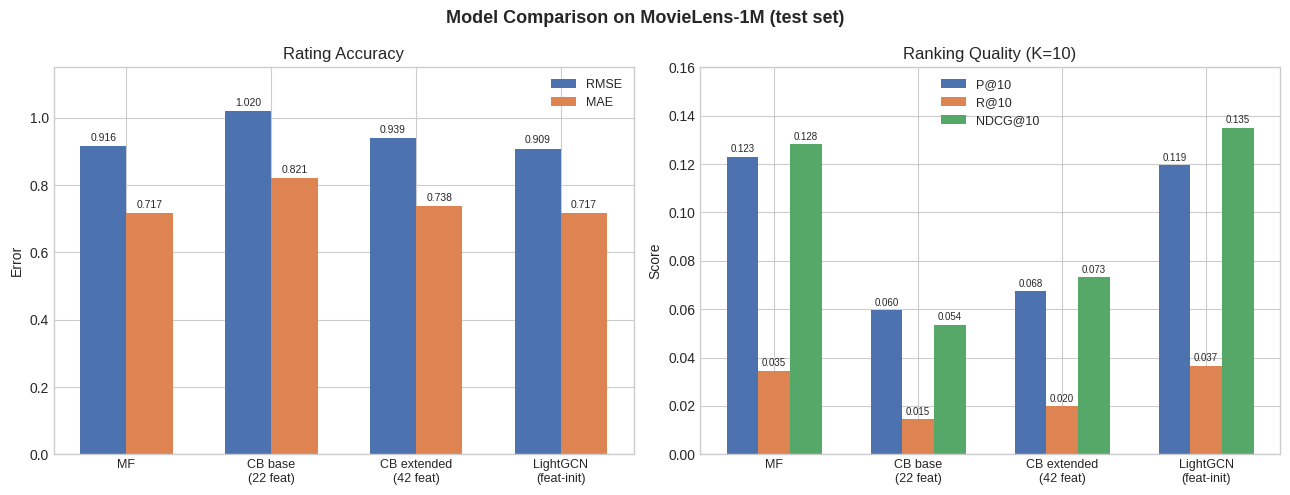

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison on MovieLens-1M (test set)', fontsize=13, fontweight='bold')

models_short = ['MF', 'CB base\n(22 feat)', 'CB extended\n(42 feat)', 'LightGCN\n(feat-init)']
colours      = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
x            = np.arange(len(models_short))
bar_width    = 0.32

# --- Left: RMSE and MAE ---
ax = axes[0]
b1 = ax.bar(x - bar_width/2, df_results['RMSE'], bar_width, label='RMSE', color=colours[0])
b2 = ax.bar(x + bar_width/2, df_results['MAE'],  bar_width, label='MAE',  color=colours[1])
ax.set_xticks(x); ax.set_xticklabels(models_short, fontsize=9)
ax.set_ylabel('Error'); ax.set_title('Rating Accuracy')
ax.set_ylim(0, 1.15)
ax.yaxis.set_minor_locator(mticker.MultipleLocator(0.05))
ax.legend(fontsize=9)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

# Right: P@10, R@10, NDCG@10
ax = axes[1]
w   = 0.22
b_p = ax.bar(x - w,   df_results['P@10'],    w, label='P@10',    color=colours[0])
b_r = ax.bar(x,       df_results['R@10'],    w, label='R@10',    color=colours[1])
b_n = ax.bar(x + w,   df_results['NDCG@10'], w, label='NDCG@10', color=colours[2])
ax.set_xticks(x); ax.set_xticklabels(models_short, fontsize=9)
ax.set_ylabel('Score'); ax.set_title('Ranking Quality (K=10)')
ax.set_ylim(0, 0.16)
ax.legend(fontsize=9)
for bar in list(b_p) + list(b_r) + list(b_n):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Discussion

**Rating accuracy.** Feature-augmented LightGCN attains the lowest RMSE (0.9087) and is essentially tied with MF on MAE (0.7175 versus 0.7170). MF is second on RMSE (0.9155). CatBoost extended (0.9387, 0.7378) trails both, and CatBoost base, using only the raw side-information $z_u$ and $x_i$, is furthest behind (RMSE 1.0195). The 0.03 RMSE gap between LightGCN and CatBoost extended is the cost of relying purely on hand-crafted features without collaborative signal; the 0.007 gain over MF is the value added by graph propagation and feature injection on top of free ID embeddings.

**Ranking quality.** LightGCN obtains the best NDCG@10 (0.1350) and Recall@10 (0.0366), while MF retains a small edge on Precision@10 (0.1230 versus 0.1195). The CatBoost models score markedly lower (P@10 $\le$ 0.0675, NDCG@10 $\le$ 0.0733), a consequence of their pointwise learning objective: minimising per-rating error does not directly optimise the ordering of items for a user. LightGCN's ranking edge over MF on NDCG and recall indicates that two-hop graph propagation reaches relevant items the user has not yet rated and pushes them up the list.

**Paradigm interpretation.** The results support the three-way paradigm distinction set out in Chapter 2. The graph-plus-feature model wins on three of the five metrics because it combines the per-user personalisation of free ID embeddings $e_u$, the side-information signal $W_u z_u$, and neighbourhood smoothing through LightGCN propagation. Interaction-only MF retains its edge on Precision@10 thanks to per-rating SGD, yet loses on RMSE, Recall@10 and NDCG@10. The feature-driven CatBoost models do well on rating prediction once rich engineered statistics are added, but never learn the embedding geometry needed for high-quality ranking. The pattern matches the theoretical expectation: collaborative signal dominates ranking, and combining side-information with a graph yields a strict improvement over either ingredient alone.